# Test the definition of a single-process 3AFC linear ballistic accumulator model

This model groups choices into a correct choice (accumulator 1) and incorrect choices (accumulators 2 and 3).

In [1]:
import os
import numpy as np
from scipy import integrate
import pandas as pd
import seaborn as sns
from devreact import model
from devreact import figures

figures.set_style()

## Generate data

In [2]:
rng = np.random.default_rng()
nt = 10000
n = np.repeat([1, 2], int(nt / 2))
s = 1
τ = 0.5
A = 4
b = 5
v1 = 3
v2 = 1.5
sim_response = model.random_single(n, s, τ, A, b, v1, v2, rng, size=(nt, 2))

## Evaluate PDF

In [3]:
# set times and responses to evaluate
i = 100  # number of times
j = 2  # number of choices
k = 2  # trial types
max_time = 4
trial_type = np.repeat([1, 2], i * j)
response = np.tile(np.repeat(range(j), i), k)
time = np.tile(np.linspace(0, max_time, i), j * k)

sweep = pd.DataFrame(
    {
        'trial_type': trial_type,
        'response': response,
        'response_time': time,
        'pdf': np.zeros(i * j * k),
    }
)

In [4]:
f = model.function_pdf_single()
rmat = sweep[['response', 'response_time']].to_numpy().astype('float64')
n_sweep = sweep['trial_type'].to_numpy().astype('int32')
sweep['pdf'] = f(rmat, n_sweep, s, τ, A, b, v1, v2)

In [5]:
(
    sweep.groupby('trial_type')[['response_time', 'pdf']]
    .apply(lambda subs: integrate.trapz(subs['pdf'], subs['response_time']))
)

trial_type
1    0.996591
2    0.996591
dtype: float64

## Compare generated data to PDF

In [6]:
sim = model.response_dataframe(sim_response, n)
sim_kwargs = {
    'x': 'Response time',
    'col': 'Response',
    'kind': 'kde',
    'col_order': ['Correct', 'Incorrect'], 
    'height': 4,
}
pdf_kwargs = {'x': 'response_time', 'y': 'pdf', 'color': 'C1'}

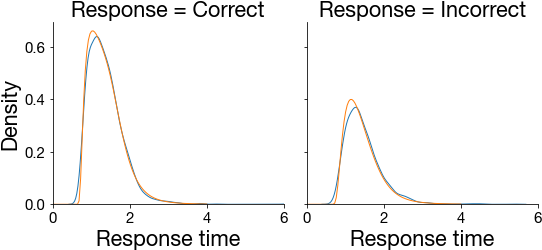

In [7]:
g = sns.displot(data=sim.loc[sim['Trial type'] == 'Direct', :], **sim_kwargs)
g.set(xlim=(0, 6))

sns.lineplot(
    data=sweep.query('trial_type == 1 and response == 1'), 
    ax=g.axes[0, 0],
    **pdf_kwargs,
)
sns.lineplot(
    data=sweep.query('trial_type == 1 and response == 0'),
    ax=g.axes[0, 1],
    **pdf_kwargs,
);

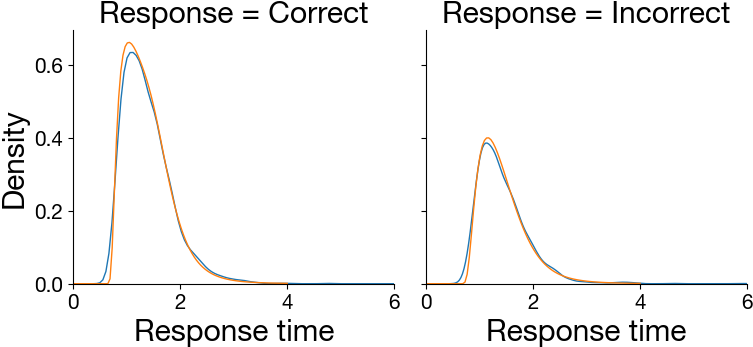

In [8]:
g = sns.displot(data=sim.loc[sim['Trial type'] == 'Indirect', :], **sim_kwargs)
g.set(xlim=(0, 6))

sns.lineplot(
    data=sweep.query('trial_type == 2 and response == 1'), 
    ax=g.axes[0, 0],
    **pdf_kwargs,
)
sns.lineplot(
    data=sweep.query('trial_type == 2 and response == 0'),
    ax=g.axes[0, 1],
    **pdf_kwargs,
);

In [9]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.4
IPython version      : 8.3.0

scipy   : 1.7.3
seaborn : 0.11.2
numpy   : 1.22.1
devreact: 0.1.0
pandas  : 1.4.2

